In [32]:
pip install pyroot

Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import numpy as np

path = "/home/levi/Área de Trabalho/Jupyter/Codes/all_events_raw_v5_sv_weight.csv"
df = pd.read_csv(path)

# Mapeamento por valores de cross_section_pb (valores que você forneceu)
# Observação: todos pp_hh serão "pp_hh" (sinal)
xsec_to_process = {
    0.00019551555000000003: "pp_hh",
    0.00019548161: "pp_hh",
    0.00019537009000000001: "pp_hh",
    0.00019546949: "pp_hh",
    0.00019547433: "pp_hh",
    0.00019517858000000002: "pp_hh",
    0.00019538221000000002: "pp_hh",
    0.00019525615: "pp_hh",
    0.00019543312: "pp_hh",

    0.41527337000000003: "pp_zz",
    0.41514270000000003: "pp_zz",
    0.4158188500000001: "pp_zz",
    0.41576596: "pp_zz",
    0.41524018: "pp_zz",
    0.41553159: "pp_zz",
    0.4154704: "pp_zz",
    0.41555751: "pp_zz",
    0.41561455: "pp_zz",
    0.41538952: "pp_zz",

    0.0066212769000000005: "pp_hjj_2mu",
    7621929600.000001: "pp_jj",       # cuidado: confira esse valor no CSV se for diferente
    1393.5323: "pp_jjmumu",
    24669.015000000007: "pp_tt",
    13098.517: "pp_zjj_2b",
    2987.982200000001: "pp_zjj_2mu",
}

# Função que tenta mapear por aproximação numérica (isclose)
def map_xsec_approx(val, xsec_keys, rtol=1e-8, atol=1e-12):
    if pd.isna(val):
        return None
    for k in xsec_keys:
        try:
            if np.isclose(float(val), float(k), rtol=rtol, atol=atol):
                return xsec_to_process[k]
        except Exception:
            continue
    return None

# 1) Tentar mapear por aproximação em cross_section_pb
xsec_keys = list(xsec_to_process.keys())
df["process"] = df["cross_section_pb"].apply(lambda v: map_xsec_approx(v, xsec_keys))

# 2) Se ainda houver NaNs em process, tentar mapear a partir da coluna 'file' (se existir)
#    Ex.: 'pp_hh_1.hepmc' -> 'pp_hh' (ou 'pp_hh' agrupado)
if "file" in df.columns:
    def map_from_filename(fname):
        if pd.isna(fname):
            return None
        s = str(fname).lower()
        # verifica padrões conhecidos
        if "pp_hh" in s:
            return "pp_hh"
        if "pp_zz" in s:
            return "pp_zz"
        if "pp_jj" in s and "pp_jjmumu" not in s and "pp_jj." in s or s.endswith("pp_jj.hepmc") or "pp_jj_" in s:
            # cuidado com nomes parecidos; caso precise ajuste a condição acima
            return "pp_jj"
        if "pp_jjmumu" in s:
            return "pp_jjmumu"
        if "pp_hjj_2mu" in s:
            return "pp_hjj_2mu"
        if "pp_tt" in s:
            return "pp_tt"
        if "pp_zjj_2b" in s:
            return "pp_zjj_2b"
        if "pp_zjj_2mu" in s:
            return "pp_zjj_2mu"
        # fallback por prefixo 'pp_zz' etc.
        for prefix in ["pp_hh", "pp_zz", "pp_jj", "pp_tt", "pp_zjj", "pp_hjj", "pp_jjmumu"]:
            if prefix in s:
                return prefix
        return None

    # só preenche onde ainda for NaN
    mask_unmapped = df["process"].isna()
    df.loc[mask_unmapped, "process"] = df.loc[mask_unmapped, "file"].apply(map_from_filename)

# 3) Se ainda houver eventos não mapeados, tentar mapear por arredondamento (ex.: 6-8 casas)
def map_by_round(val, places=6):
    if pd.isna(val):
        return None
    try:
        rounded = round(float(val), places)
    except Exception:
        return None
    for k in xsec_keys:
        if round(float(k), places) == rounded:
            return xsec_to_process[k]
    return None

mask_unmapped = df["process"].isna()
df.loc[mask_unmapped, "process"] = df.loc[mask_unmapped, "cross_section_pb"].apply(lambda v: map_by_round(v, places=6))

# Diagnóstico: total, mapeado, não mapeado
total_events = len(df)
mapped_events = df["process"].notna().sum()
unmapped_events = total_events - mapped_events

print(f"Total de eventos no CSV: {total_events}")
print(f"Eventos mapeados para 'process': {mapped_events}")
print(f"Eventos NÃO mapeados: {unmapped_events}")
print()

# Mostrar contagem por processo (ordenado)
counts = df["process"].value_counts(dropna=False).rename_axis("process").reset_index(name="num_events")
print(counts)

# Exibir algumas linhas não mapeadas para inspeção (se houver)
if unmapped_events > 0:
    print("\nAmostra de eventos não mapeados (primeiras 20 linhas):")
    display_cols = [c for c in ["file", "cross_section_pb", "process"] if c in df.columns]
    print(df[df["process"].isna()][display_cols].head(20).to_string(index=False))


Total de eventos no CSV: 101604
Eventos mapeados para 'process': 101604
Eventos NÃO mapeados: 0

      process  num_events
0       pp_hh       86825
1  pp_hjj_2mu       12182
2   pp_jjmumu        1675
3  pp_zjj_2mu         698
4       pp_tt         161
5       pp_zz          63


In [37]:
import pandas as pd

# Caminho do arquivo
path = "/home/levi/Área de Trabalho/Jupyter/Codes/all_events_raw_v5_sv_weight.csv"

# Carrega o CSV
df = pd.read_csv(path)

# Aplica o corte: 123 < muon_mass < 126
df_cortado = df[(df['muon_mass'] > 123) & (df['muon_mass'] < 126)]

# Opcional: salvar o arquivo filtrado
df_cortado.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut_v2.csv", index=False)

print("Eventos antes:", len(df))
print("Eventos depois:", len(df_cortado))


Eventos antes: 101604
Eventos depois: 86762


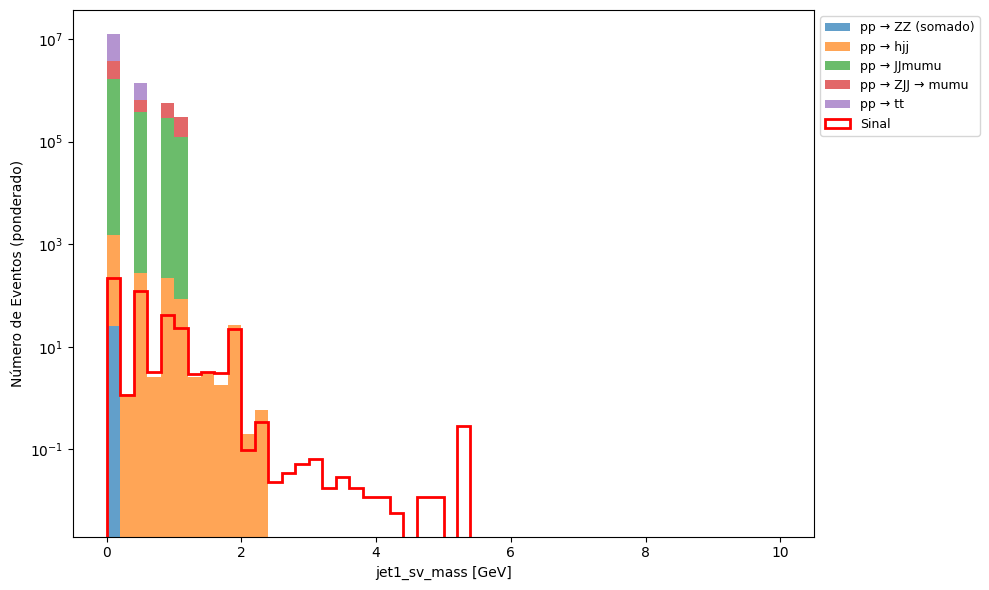

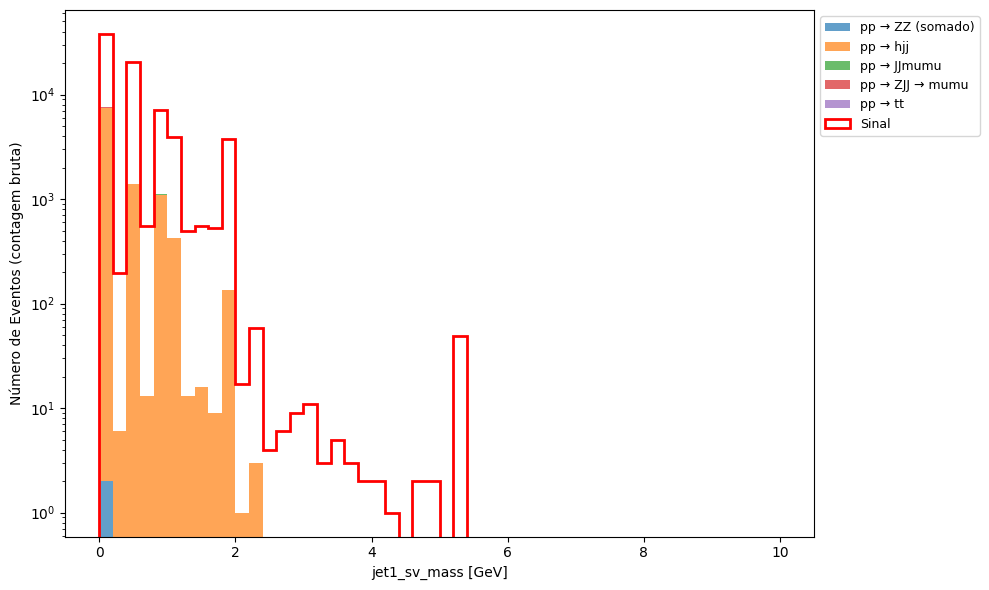

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut_v2.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet1_sv_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_mass'], bins=50, range=(0, 10),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet1_sv_mass [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_mass'], bins=50, range=(0, 10),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet1_sv_mass [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


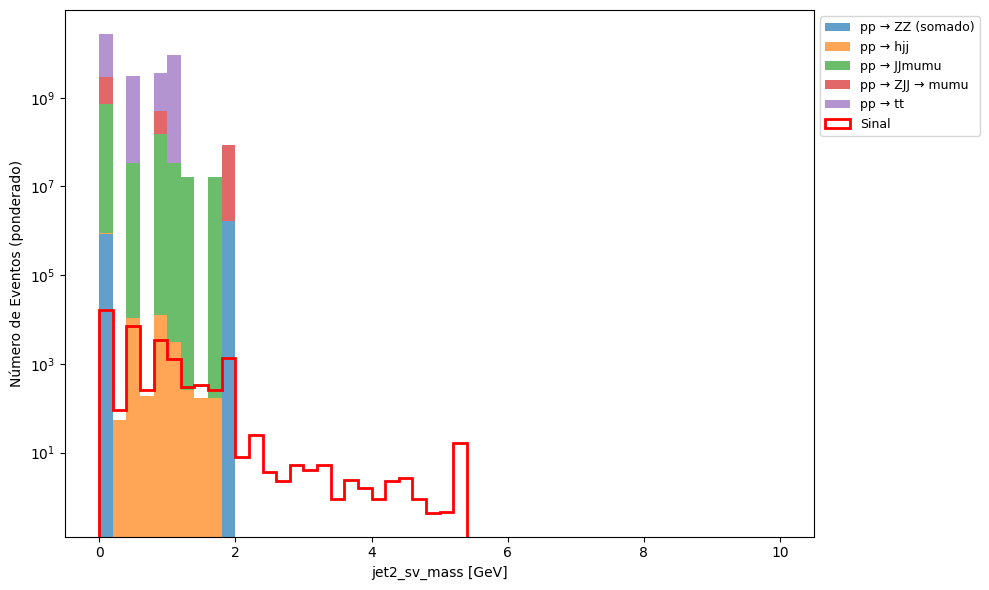

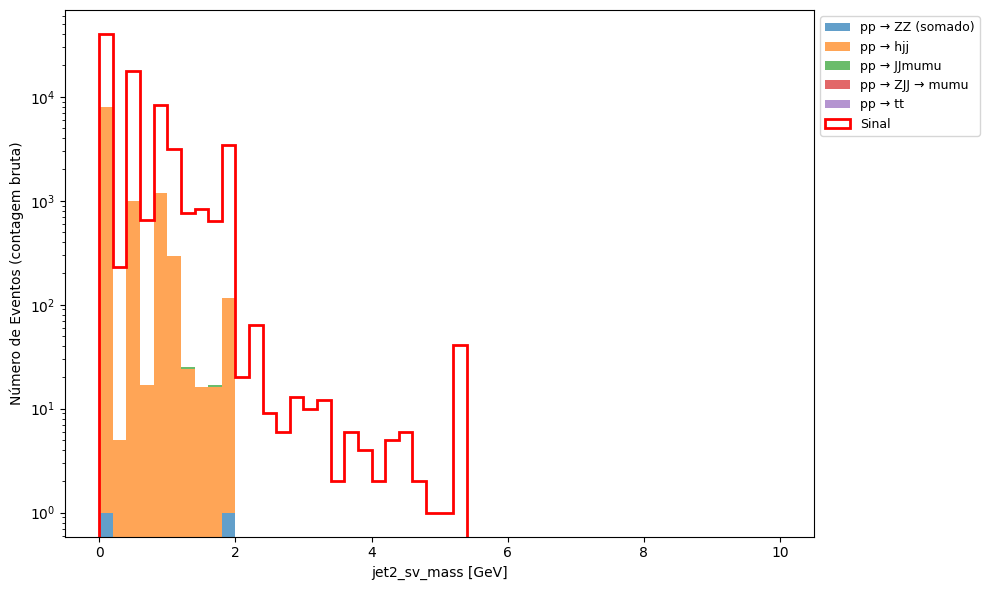

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet2_sv_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet2_sv_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_mass'], bins=50, range=(0, 10),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet2_sv_mass [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 10),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_mass'], bins=50, range=(0, 10),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet2_sv_mass [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


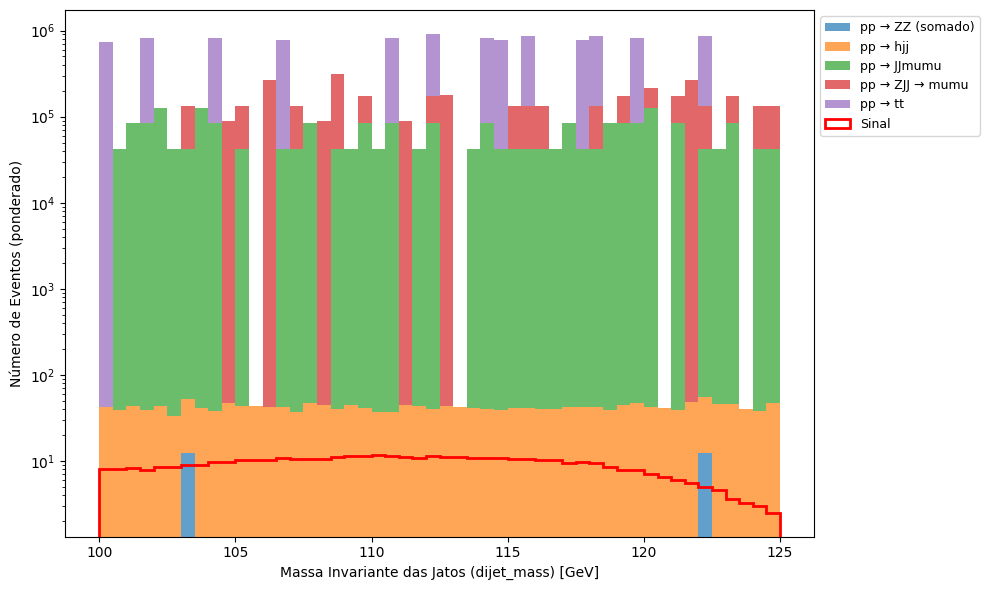

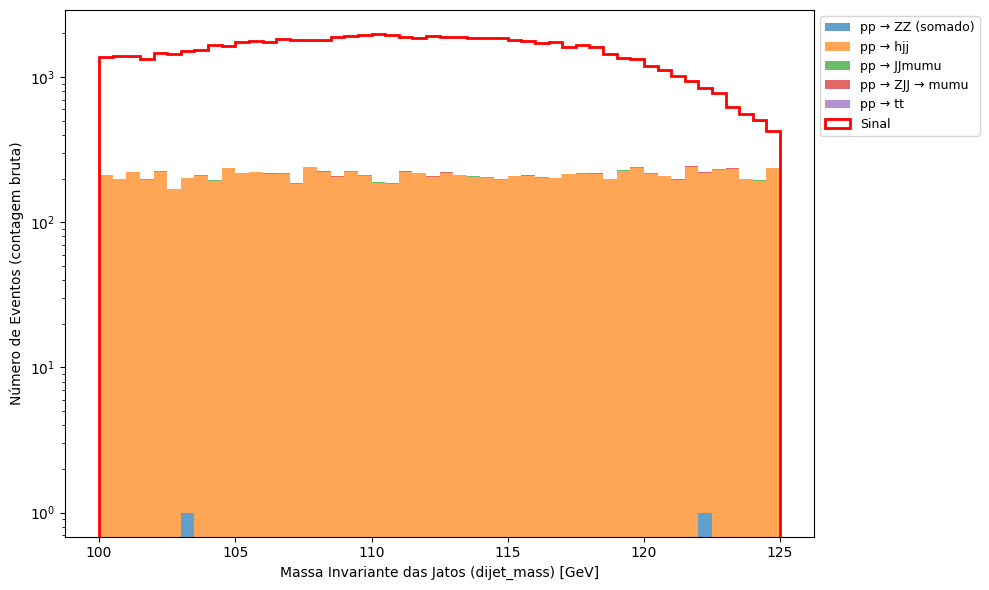

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut_v2.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['dijet_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['dijet_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(100, 125),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['dijet_mass'], bins=50, range=(100, 125),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('Massa Invariante das Jatos (dijet_mass) [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/dijet_mass_com_peso_log.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(100, 125),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['dijet_mass'], bins=50, range=(100, 125),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('Massa Invariante das Jatos (dijet_mass) [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
plt.savefig("//home/levi/Área de Trabalho/Jupyter/Codes/dijet_mass_sem_peso_log.png", dpi=100, bbox_inches='tight')
plt.show()


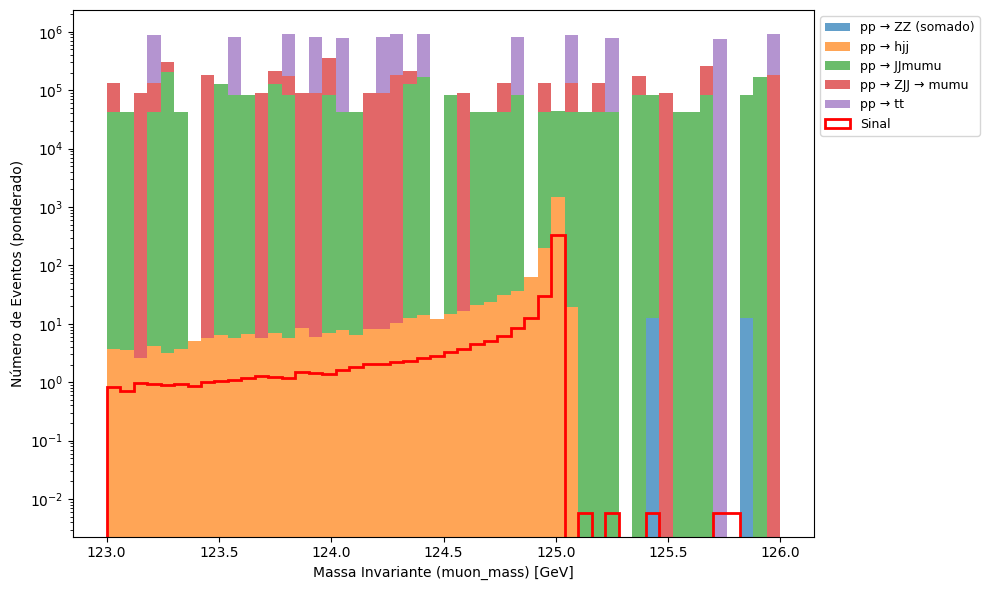

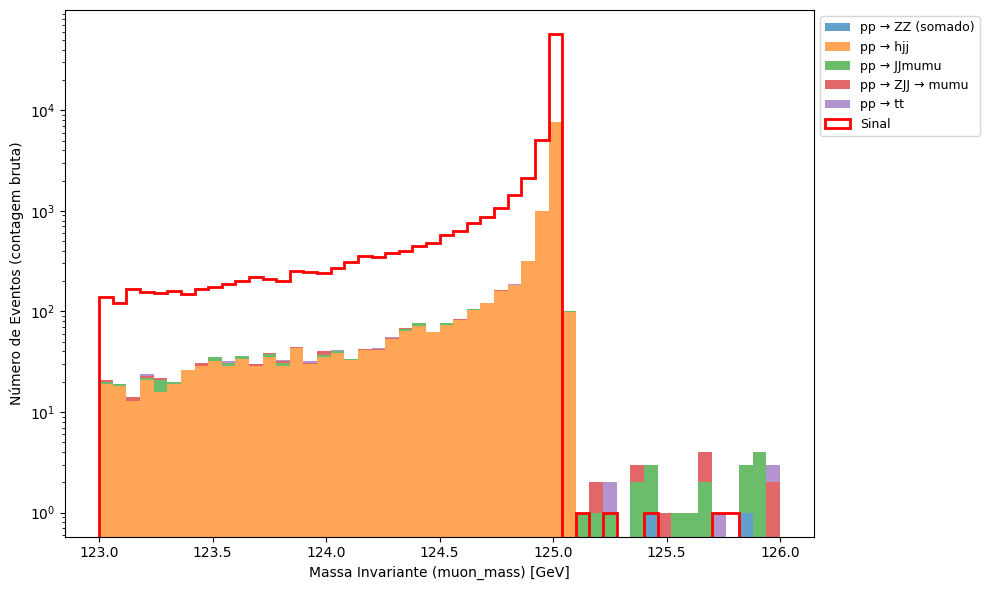

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut_v2.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['muon_mass'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue  # <-- remove completamente o background desconhecido

    bkg_datasets.append(group['muon_mass'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(123, 126), weights=bkg_weights,
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['muon_mass'], bins=50, range=(123, 126),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('Massa Invariante (muon_mass) [GeV]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de dimuons (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/massa_muons_com_peso_log.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(123, 126), stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['muon_mass'], bins=50, range=(123, 126),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('Massa Invariante (muon_mass) [GeV]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de dimuons (sem pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/massa_muons_sem_peso_log.png", dpi=100, bbox_inches='tight')
plt.show()


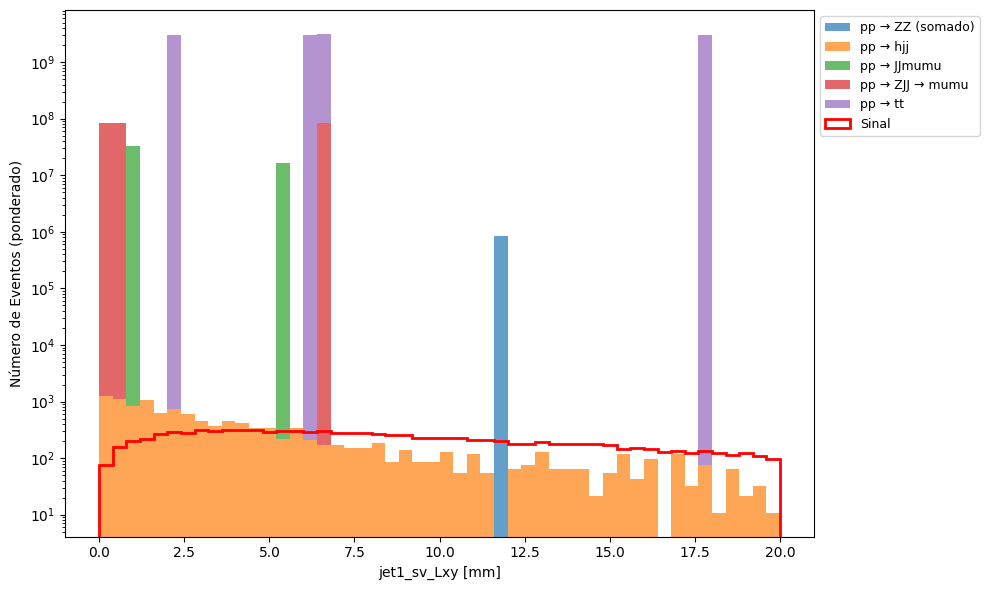

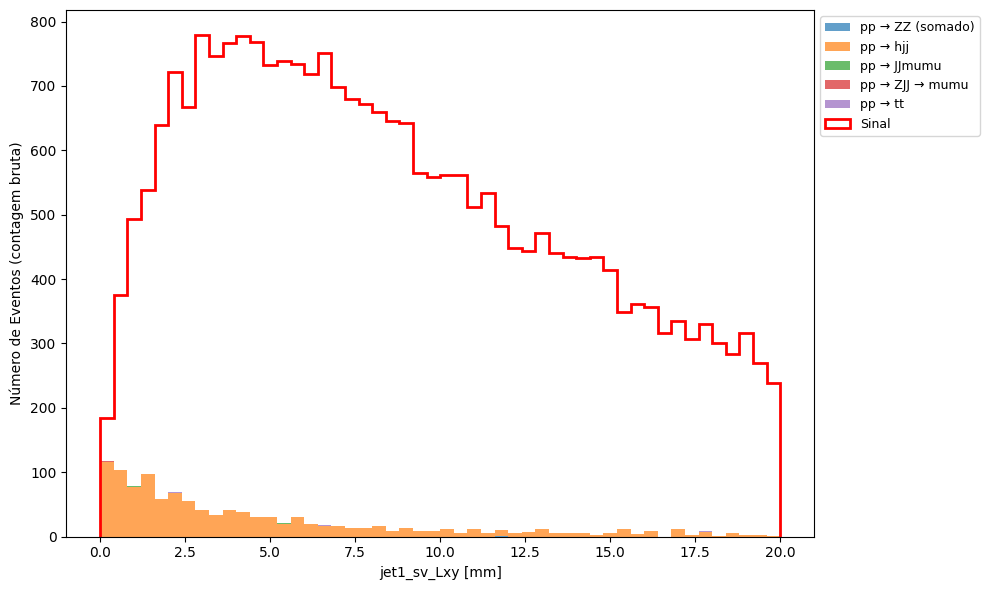

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_Lxy'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet1_sv_Lxy'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001, 20),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_Lxy'], bins=50, range=(0.001, 20),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet1_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001,20),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_Lxy'], bins=50, range=(0.001, 20),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet1_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


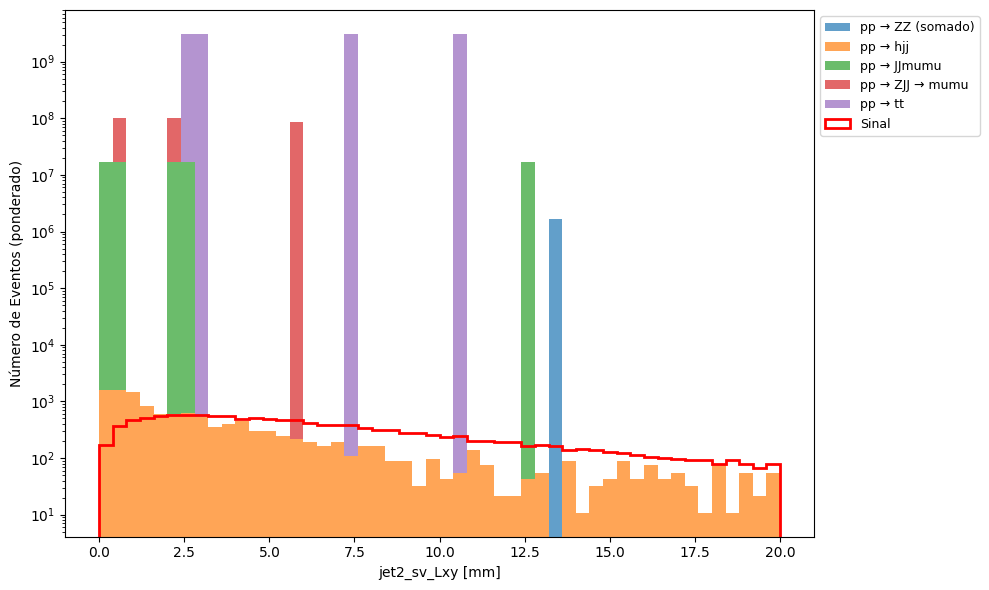

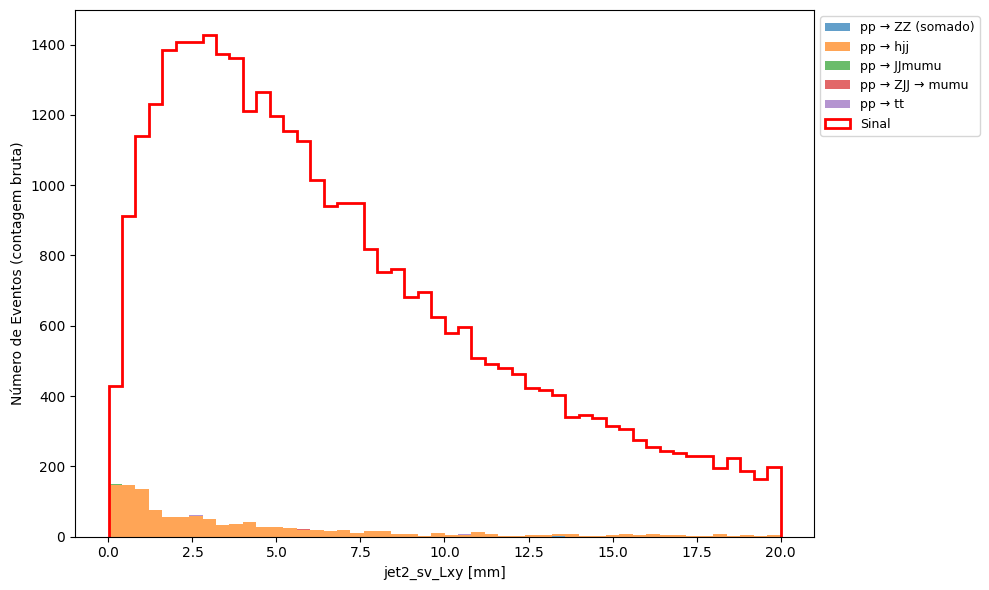

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet2_sv_Lxy'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet2_sv_Lxy'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001, 20),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_Lxy'], bins=50, range=(0.001, 20),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet2_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0.001, 20),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_Lxy'], bins=50, range=(0.001, 20),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet2_sv_Lxy [mm]')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


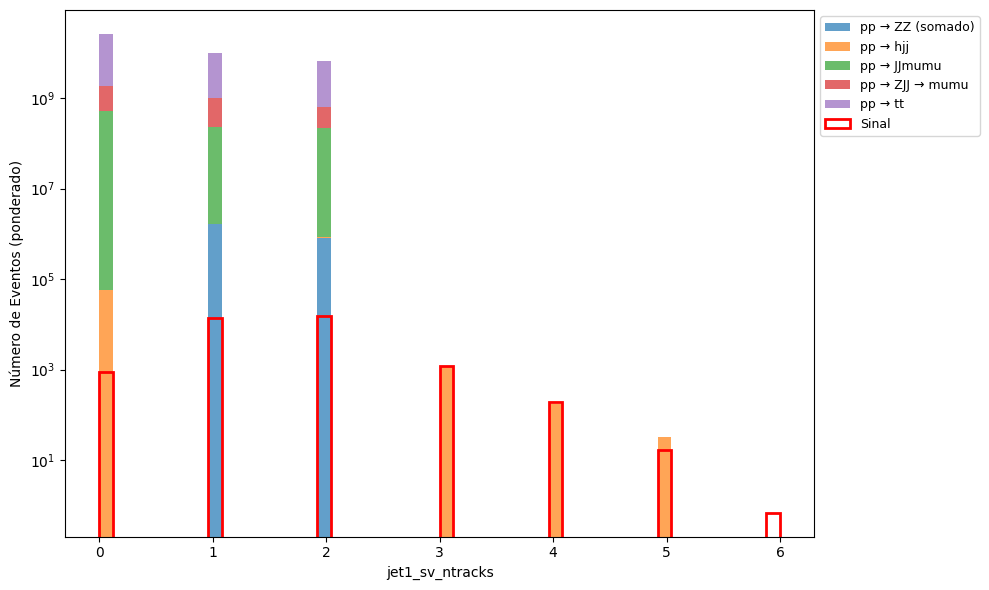

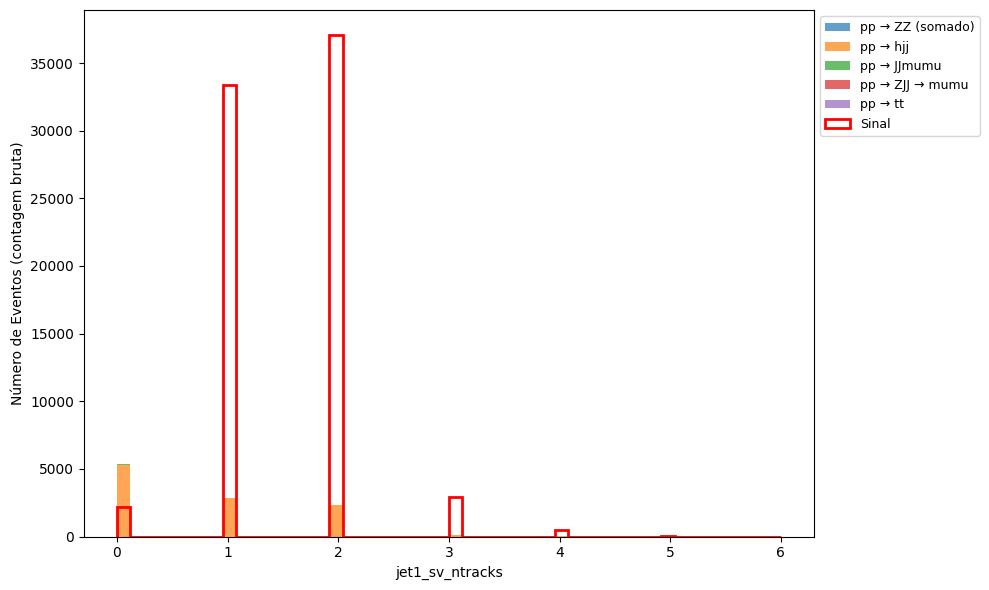

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_ntracks'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet1_sv_ntracks'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_ntracks'], bins=50, range=(0, 6),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet1_sv_ntracks')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet1_sv_ntracks'], bins=50, range=(0, 6),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet1_sv_ntracks')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


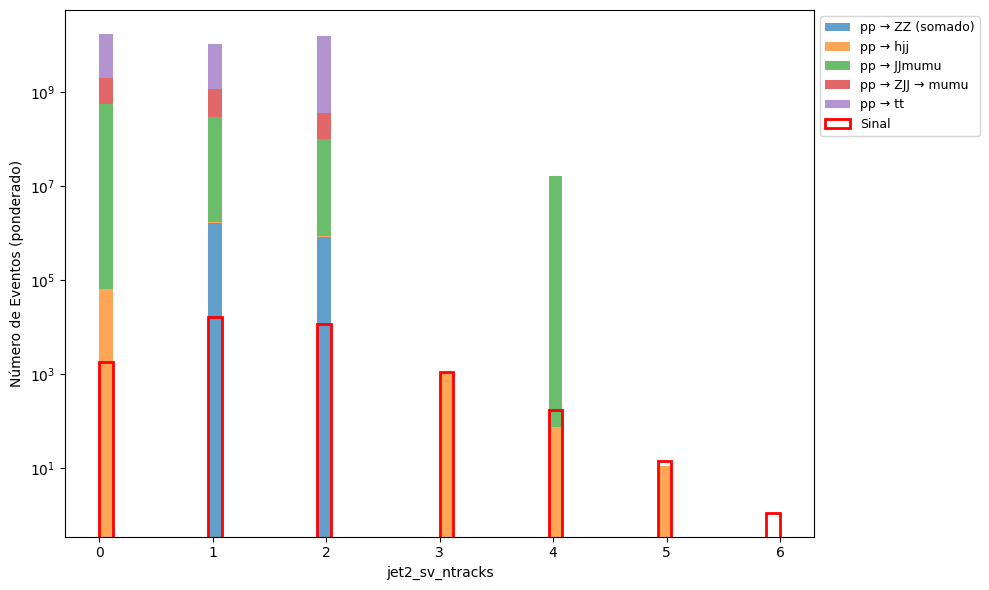

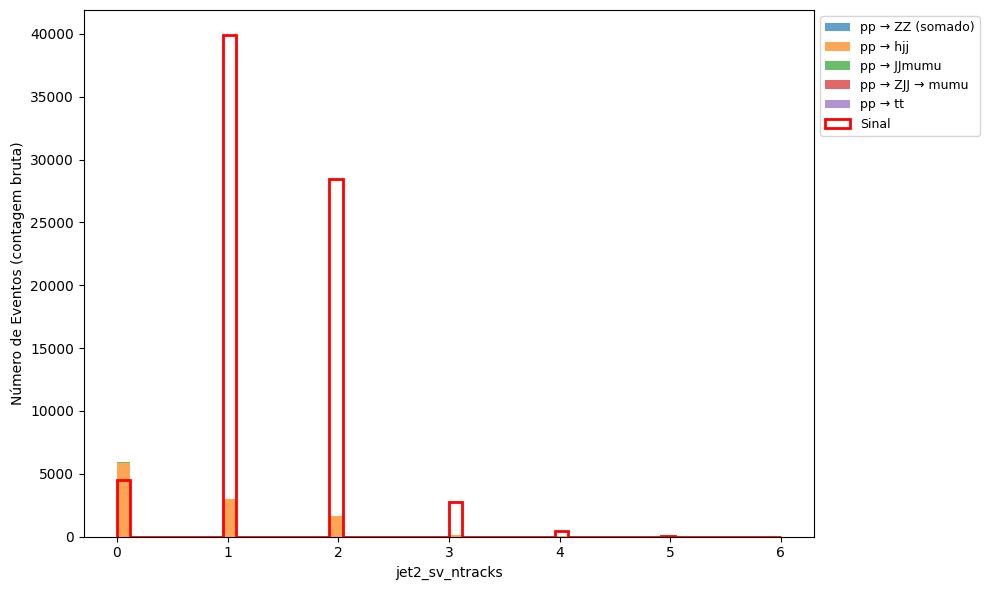

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================
# CARREGAR DADOS
# ============================
data = pd.read_csv('/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut.csv')

# Separar sinal e backgrounds
sinal = data[data['label'] == 1]
backgrounds = data[data['label'] == 0]

# ============================
# AGRUPAMENTO DO PROCESSO pp → ZZ (somado)
# ============================
ppzz_cross_sections = [
    0.4151427, 0.41524018, 0.41527337, 0.41538952, 0.4154704,
    0.41553159, 0.41555751, 0.41561455, 0.41576596, 0.41581885
]

# ============================
# NOMES COM VALORES EXATOS
# ============================
nome_backgrounds = {
    0.0066212769: "pp → hjj",
    1393.5323: "pp → JJmumu",
    2987.982200000001: "pp → ZJJ → mumu",
    24669.015000000007: "pp → tt"
}

# Função utilitária: busca tolerante
def get_nome_por_cs(cs_value, nome_dict, rtol=1e-6, atol=1e-9):
    for k, nome in nome_dict.items():
        if np.isclose(k, cs_value, rtol=rtol, atol=atol):
            return nome
    return None

bkg_datasets = []
bkg_weights = []
bkg_labels = []

# Agrupar pp → ZZ
ppzz_group = backgrounds[backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]
if not ppzz_group.empty:
    bkg_datasets.append(ppzz_group['jet1_sv_ntracks'])
    bkg_weights.append(ppzz_group['weight'])
    bkg_labels.append('pp → ZZ (somado)')

# Outros backgrounds
other_bkgs = backgrounds[~backgrounds['cross_section_pb'].isin(ppzz_cross_sections)]

for cs_pb, group in other_bkgs.groupby('cross_section_pb'):
    nome_correspondente = get_nome_por_cs(cs_pb, nome_backgrounds)
    if nome_correspondente is None:
        continue

    bkg_datasets.append(group['jet2_sv_ntracks'])
    bkg_weights.append(group['weight'])
    bkg_labels.append(nome_correspondente)

# ============================
# PLOT 1 – COM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         weights=bkg_weights, stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_ntracks'], bins=50, range=(0, 6),
         weights=sinal['weight'], histtype='step', linewidth=2,
         color='red', label='Sinal')

plt.xlabel('jet2_sv_ntracks')
plt.ylabel('Número de Eventos (ponderado)')
#plt.title('Distribuição de Massa Invariante de jatos (com pesos)')
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_com_peso.png", dpi=100, bbox_inches='tight')
plt.show()

# ============================
# PLOT 2 – SEM PESOS
# ============================
plt.figure(figsize=(10, 6))

plt.hist(bkg_datasets, bins=50, range=(0, 6),
         stacked=True, alpha=0.7, label=bkg_labels)

plt.hist(sinal['jet2_sv_ntracks'], bins=50, range=(0, 6),
         histtype='step', linewidth=2, color='red', label='Sinal')

plt.xlabel('jet2_sv_ntracks')
plt.ylabel('Número de Eventos (contagem bruta)')
#plt.title('Distribuição de Massa Invariante de jatos (sem pesos)')
#plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1.0, 1), fontsize=9)
plt.tight_layout()
#plt.savefig("/home/lphelipe/Monografia_imagens/dijet_mass_sem_peso.png", dpi=100, bbox_inches='tight')
plt.show()


In [40]:
caminho_arquivo = '/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut_v2.csv'

In [41]:
# Lendo apenas o cabeçalho do arquivo CSV
try:
    df = pd.read_csv(caminho_arquivo, nrows=0)  # nrows=0 lê apenas o cabeçalho
    
    # Obtendo os nomes das colunas
    colunas = df.columns.tolist()
    
    # Imprimindo os nomes das colunas
    print("Nomes das colunas no arquivo CSV:")
    for i, coluna in enumerate(colunas, 1):
        print(f"{i}. {coluna}")
        
except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado no caminho {caminho_arquivo}")
except Exception as e:
    print(f"Ocorreu um erro ao ler o arquivo: {e}")

Nomes das colunas no arquivo CSV:
1. muon_mass
2. muon1_pt
3. muon2_pt
4. muon1_eta
5. muon2_eta
6. dimuon_eta
7. dimuon_pt
8. dimuon_energy
9. dijet_mass
10. dihiggs_mass
11. jet1_pt
12. jet2_pt
13. jet1_eta
14. jet2_eta
15. di_jet_eta
16. di_jet_pt
17. di_jet_energy
18. delta_r
19. num_jets
20. jet1_is_b_tagged
21. jet2_is_b_tagged
22. jet1_sv_Lxy
23. jet2_sv_Lxy
24. jet1_sv_ntracks
25. jet2_sv_ntracks
26. jet1_sv_mass
27. jet2_sv_mass
28. weight
29. cross_section_pb
30. label
31. process
32. sum_weights


In [42]:
import pandas as pd

# Carregar o CSV original
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/all_events_muonMassCut_v2.csv")

# Separar pelos labels
df_0 = df[df["label"] == 0].sample(frac=1, random_state=42).reset_index(drop=True)
df_1 = df[df["label"] == 1].sample(frac=1, random_state=42).reset_index(drop=True)

# Dividir ao meio cada grupo
half_0 = len(df_0) // 2
half_1 = len(df_1) // 2

# Criar os arquivos balanceados
arquivo_1 = pd.concat([df_0.iloc[:half_0], df_1.iloc[:half_1]]).sample(frac=1, random_state=42).reset_index(drop=True)
arquivo_2 = pd.concat([df_0.iloc[half_0:], df_1.iloc[half_1:]]).sample(frac=1, random_state=42).reset_index(drop=True)

# Salvar arquivos
arquivo_1.to_csv("dados_independentes_v2.csv", index=False)
arquivo_2.to_csv("dados_treino_v2.csv", index=False)

print("dados_independentes salvo com", len(arquivo_1), "eventos")
print("dados_treino salvo com", len(arquivo_2), "eventos")


dados_independentes salvo com 43380 eventos
dados_treino salvo com 43382 eventos


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
from sklearn.metrics import accuracy_score

# ===============================
# 1. Carregar o arquivo CSV
# ===============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/dados_treino_v2.csv")

# Separar features (X), labels (y) e pesos
X = df.drop(['label', 'weight', 'sum_weights', 'jet1_is_b_tagged', 'jet2_is_b_tagged', 'cross_section_pb', 'process', 'sum_weights'], axis=1)
y = df['label']
weights = df['weight']

# ===============================
# 2. Dividir em treino e teste
# ===============================
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 3. Normalizar (escalar) os dados
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 4. Calcular o balanceamento de classes
# ===============================
scale_pos_weight = len(weights_train[y_train == 0]) / len(weights_train[y_train == 1])

# ===============================
# 5. Criar e treinar o modelo
# ===============================
model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=50000, # Ref:200 ; Best:1500; 12000
    max_depth=32, # Ref:8 ; Best:8; 32
    learning_rate=0.01, # Ref:0.05 ; Best:0.01 ; 0.01
    subsample=0.6, # Ref:0.8 ; Best:0.6 ; 0.6
    colsample_bytree=0.6, # Ref:0.8 ; Best:0.6 ; 0.6
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    early_stopping_rounds=1500, # Ref:50 ; Best:350
    tree_method='hist'
)

model.fit(
    X_train_scaled,
    y_train,
    sample_weight=weights_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=10
)

# ===============================
# 6. Fazer previsões
# ===============================
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\nAcurácia:", accuracy_score(y_test, y_pred))

# ===============================
# 7. Salvar modelo e scaler
# ===============================
model.save_model("/home/levi/Área de Trabalho/Jupyter/Codes/modelo_xgb_treino_v2.json")
joblib.dump(scaler, "//home/levi/Área de Trabalho/Jupyter/Codes/scaler_xgb_treino_v2.pkl")
print("Modelo e scaler salvos com sucesso!")

# ===============================
# 8. Criar DataFrame com os scores
# ===============================
df_scores = X_test.copy()
df_scores['label'] = y_test.values
df_scores['weight'] = weights_test.values
df_scores['score'] = y_pred_proba

# ===============================
# 9. Separar sinal e background
# ===============================
signal = df_scores[df_scores['label'] == 1]
background = df_scores[df_scores['label'] == 0]

# ===============================
# 10. Salvar arquivos CSV separados
# ===============================
signal.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_signal_treino_v2.csv", index=False)
background.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_background_treino_v2.csv", index=False)

print("\nArquivos salvos com sucesso:")
print(" - scores_signal.csv")
print(" - scores_background.csv")


[0]	validation_0-aucpr:0.89519
[10]	validation_0-aucpr:0.96694
[20]	validation_0-aucpr:0.96477
[30]	validation_0-aucpr:0.96185
[40]	validation_0-aucpr:0.96971
[50]	validation_0-aucpr:0.97376
[60]	validation_0-aucpr:0.97483
[70]	validation_0-aucpr:0.97549
[80]	validation_0-aucpr:0.97671
[90]	validation_0-aucpr:0.97635
[100]	validation_0-aucpr:0.97628
[110]	validation_0-aucpr:0.97676
[120]	validation_0-aucpr:0.97705
[130]	validation_0-aucpr:0.97733
[140]	validation_0-aucpr:0.97743
[150]	validation_0-aucpr:0.97773
[160]	validation_0-aucpr:0.97777
[170]	validation_0-aucpr:0.97779
[180]	validation_0-aucpr:0.97828
[190]	validation_0-aucpr:0.97874
[200]	validation_0-aucpr:0.97858
[210]	validation_0-aucpr:0.97824
[220]	validation_0-aucpr:0.97815
[230]	validation_0-aucpr:0.97790
[240]	validation_0-aucpr:0.97770
[250]	validation_0-aucpr:0.97759
[260]	validation_0-aucpr:0.97741
[270]	validation_0-aucpr:0.97734
[280]	validation_0-aucpr:0.97693
[290]	validation_0-aucpr:0.97664
[300]	validation_0-au


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.27      0.97      0.42      1067
           1       0.99      0.63      0.77      7610

    accuracy                           0.67      8677
   macro avg       0.63      0.80      0.60      8677
weighted avg       0.90      0.67      0.73      8677


=== Confusion Matrix ===
[[1036   31]
 [2828 4782]]


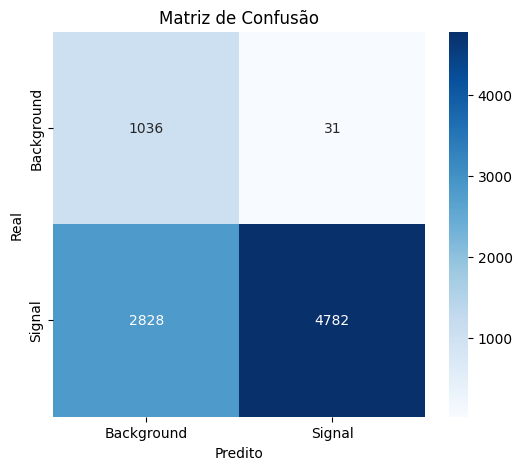

<Figure size 1200x800 with 0 Axes>

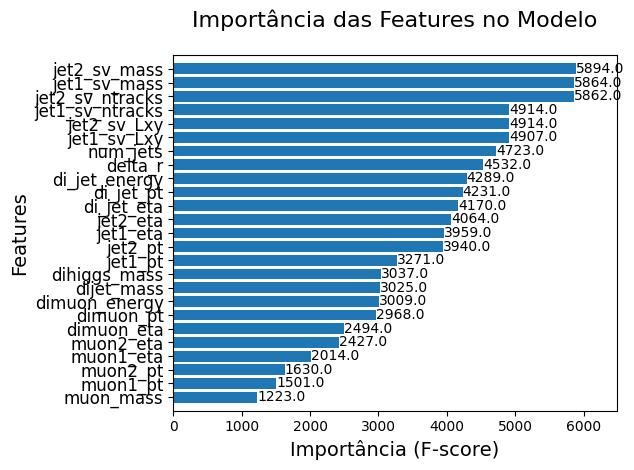

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Definir os nomes das features
feature_names = X.columns.tolist()

# 1. Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix
print("\n=== Confusion Matrix ===")
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot da Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Background', 'Signal'],
            yticklabels=['Background', 'Signal'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')

plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/matriz_confusao.png", dpi=100, bbox_inches='tight')
plt.show()

# 3. Importância das features com nomes personalizados
plt.figure(figsize=(12, 8))
ax = xgb.plot_importance(
    model, 
    max_num_features=len(feature_names), 
    height=0.8,
    importance_type='weight',
    xlabel='F-score',
    title='Importância das Features (XGBoost)',
    grid=False
)

# Ajustar os rótulos para usar os nomes corretos
ax.set_yticklabels(feature_names, fontsize=12)
ax.set_xlabel('Importância (F-score)', fontsize=14)
ax.set_ylabel('Features', fontsize=14)
ax.set_title('Importância das Features no Modelo', fontsize=16, pad=20)
plt.tight_layout()

plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/importancia_features.png", dpi=100, bbox_inches='tight')
plt.show()

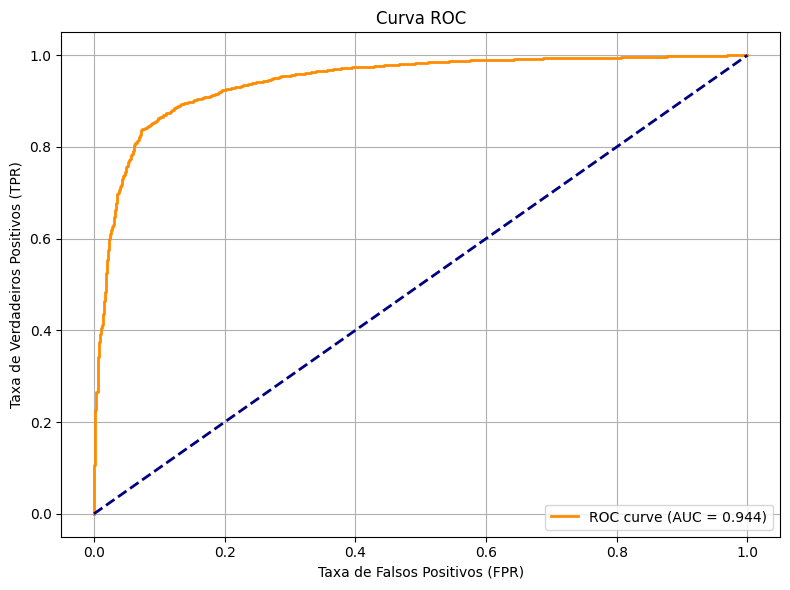

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calcular as taxas de falso positivo e verdadeiro positivo
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plotar a curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/curva_roc.png", dpi=100, bbox_inches='tight')
plt.show()


In [4]:
print(np.sum(weights_train[y_train == 0]))
print(np.sum(weights_train[y_train == 1]))

6132750.154380843
178.4345378159988


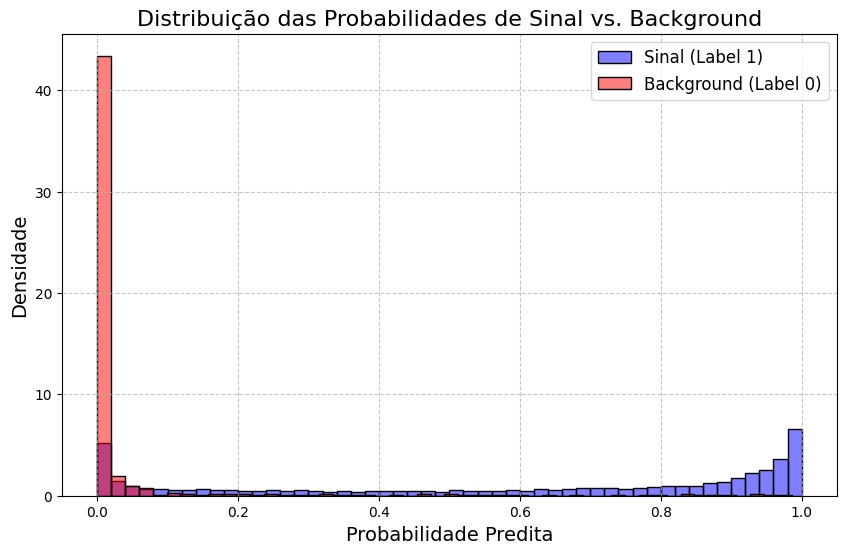

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar DataFrame com as probabilidades e labels verdadeiros
prob_df = pd.DataFrame({
    'Probability': y_pred_proba,
    'True Label': y_test
})

# Separar as probabilidades para sinal (label 1) e background (label 0)
signal_probs = prob_df[prob_df['True Label'] == 1]['Probability']
bkg_probs = prob_df[prob_df['True Label'] == 0]['Probability']

# Plotar as distribuições
plt.figure(figsize=(10, 6))
sns.histplot(signal_probs, bins=50, color='blue', alpha=0.5, label='Sinal (Label 1)', stat='density')
sns.histplot(bkg_probs, bins=50, color='red', alpha=0.5, label='Background (Label 0)', stat='density')

plt.xlabel('Probabilidade Predita', fontsize=14)
plt.ylabel('Densidade', fontsize=14)
plt.title('Distribuição das Probabilidades de Sinal vs. Background', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

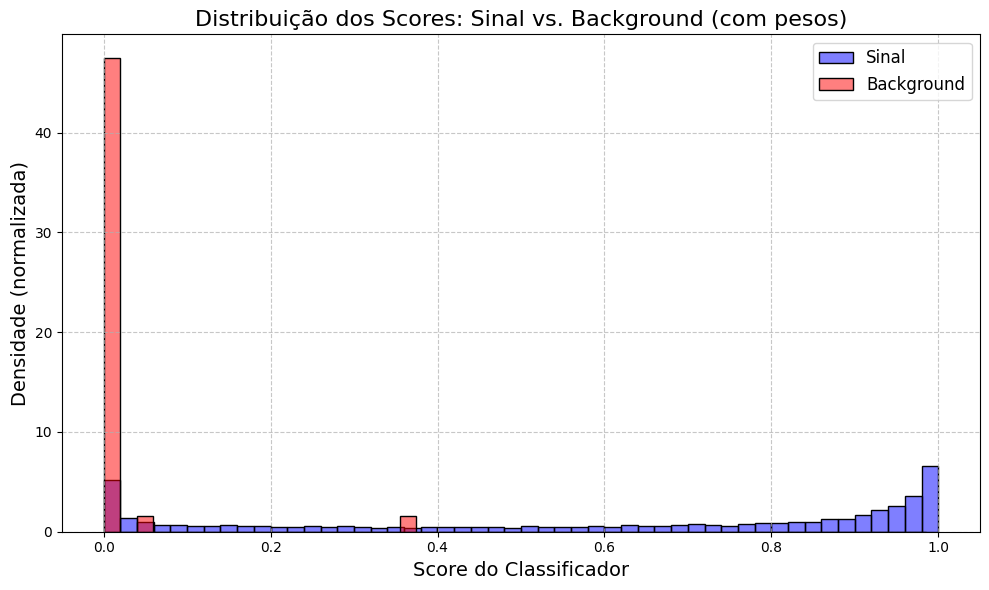

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Carregar os arquivos de scores
# -------------------------
signal = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_signal_treino_v2.csv")
background = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_background_treino_v2.csv")

# -------------------------
# Selecionar colunas de score e peso
# (ajuste o nome se necessário)
# -------------------------
signal_df = pd.DataFrame({
    'score': signal['score'],
    'weight': signal['weight']
})

background_df = pd.DataFrame({
    'score': background['score'],
    'weight': background['weight']
})

# -------------------------
# Plotar as distribuições ponderadas
# -------------------------
plt.figure(figsize=(10, 6))
sns.histplot(data=signal_df, x='score', bins=50, color='blue', alpha=0.5,
             label='Sinal', stat='density', weights='weight')
sns.histplot(data=background_df, x='score', bins=50, color='red', alpha=0.5,
             label='Background', stat='density', weights='weight')

# -------------------------
# Ajustes de visualização
# -------------------------
plt.xlabel('Score do Classificador', fontsize=14)
plt.ylabel('Densidade (normalizada)', fontsize=14)
plt.title('Distribuição dos Scores: Sinal vs. Background (com pesos)', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ===========================
# 1. Carregar o modelo e o scaler
# ===========================
model = xgb.XGBClassifier()
model.load_model("/home/levi/Área de Trabalho/Jupyter/Codes/modelo_xgb_treino_v2.json")

#scaler = joblib.load("/home/lphelipe/Cuts_code/Shape_analysis/scaler_xgb_v1.pkl")
scaler = StandardScaler()

# ===========================
# 2. Carregar o novo arquivo (dados NÃO usados no treino)
# ===========================
df_data = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/dados_independentes_v2.csv")

# Remover colunas não utilizadas no treino
X_data = df_data.drop(['label', 'weight', 'sum_weights', 'jet1_is_b_tagged', 'jet2_is_b_tagged', 'cross_section_pb', 'process', 'sum_weights'], axis=1)
weights_data = df_data['weight']
labels_data = df_data['label']  # só para referência (não será usado no fit)

# ===========================
# 3. Escalar os dados com o MESMO scaler do treino
# ===========================
X_data_scaled = scaler.fit_transform(X_data)
X_data_scaled = scaler.transform(X_data)

# ===========================
# 4. Obter scores (probabilidade de ser sinal)
# ===========================
scores = model.predict_proba(X_data_scaled)[:, 1]

# ===========================
# 5. Salvar para análise no ROOT
# ===========================

df_scores = pd.DataFrame({
    'score': scores,
    'weight': weights_data,
    'label': labels_data
})

output_df = df_scores

signal_df = df_scores[df_scores['label'] == 1]
background_df = df_scores[df_scores['label'] == 0]

signal_df.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_sinal_independentes_v2.csv", index=False)
background_df.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_background_independentes_v2.csv", index=False)
output_df.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv", index=False)

print("Scores salvos em: scores_arquivo2.csv")


Scores salvos em: scores_arquivo2.csv


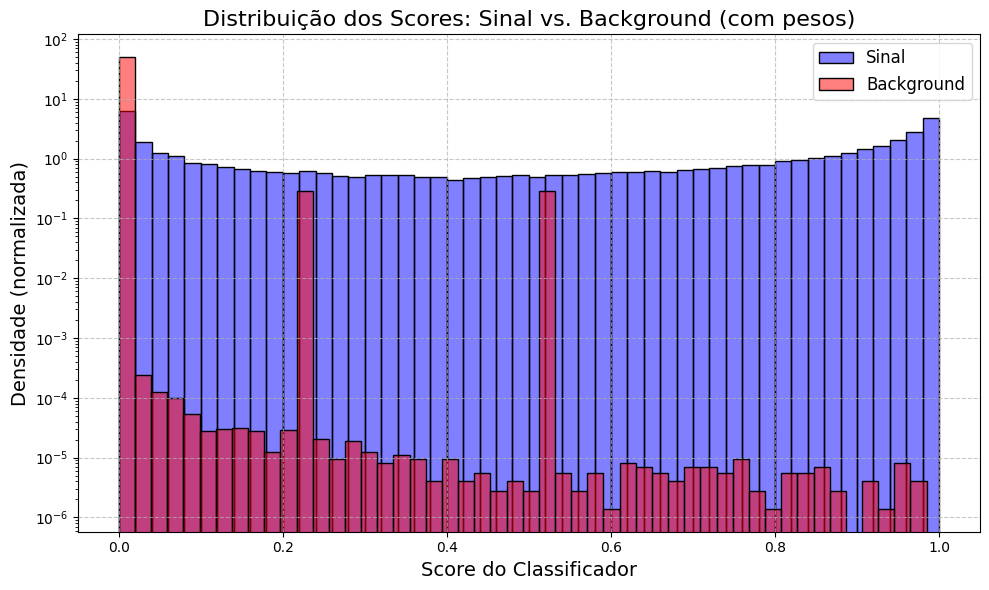

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Carregar os arquivos de scores
# -------------------------
signal = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_sinal_independentes_v2.csv")
background = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_background_independentes_v2.csv")

# -------------------------
# Selecionar colunas de score e peso
# (ajuste o nome se necessário)
# -------------------------
signal_df = pd.DataFrame({
    'score': signal['score'],
    'weight': signal['weight']
})

background_df = pd.DataFrame({
    'score': background['score'],
    'weight': background['weight']
})

# -------------------------
# Plotar as distribuições ponderadas
# -------------------------
plt.figure(figsize=(10, 6))
sns.histplot(data=signal_df, x='score', bins=50, color='blue', alpha=0.5,
             label='Sinal', stat='density', weights='weight')
sns.histplot(data=background_df, x='score', bins=50, color='red', alpha=0.5,
             label='Background', stat='density', weights='weight')

# -------------------------
# Ajustes de visualização
# -------------------------
plt.xlabel('Score do Classificador', fontsize=14)
plt.ylabel('Densidade (normalizada)', fontsize=14)
plt.title('Distribuição dos Scores: Sinal vs. Background (com pesos)', fontsize=16)
plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


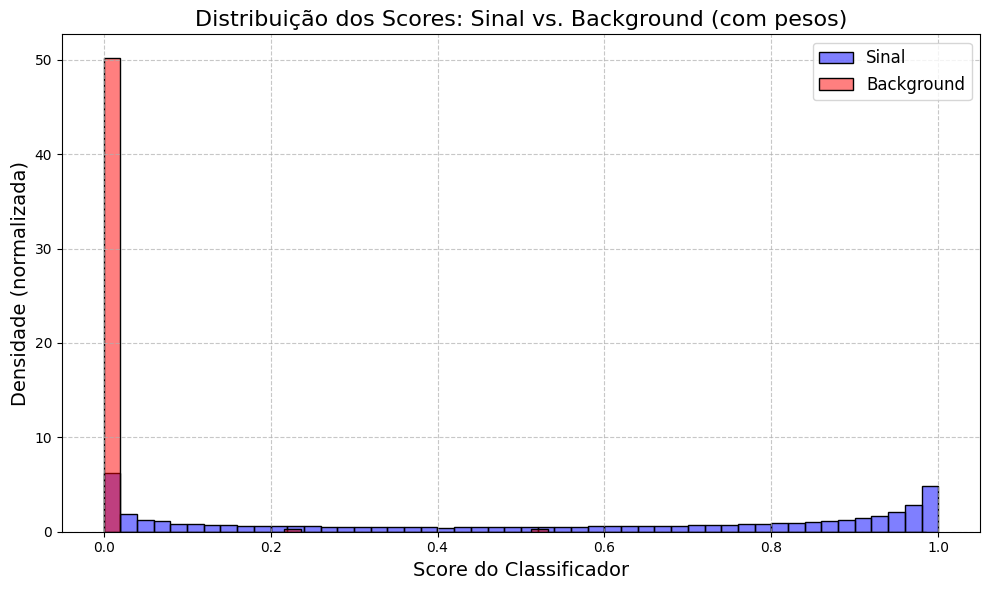

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Carregar os arquivos de scores
# -------------------------
data = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# -------------------------
# Selecionar colunas de score e peso
# (ajuste o nome se necessário)
# -------------------------
"""
data_df = pd.DataFrame({
    'score': data['score'],
    'weight': data['weight'],
    'label' : data[
})
"""

sinal_df = data[data['label'] == 1]
background_df = data[data['label'] == 0]

weight_signal = sinal_df['weight']
weight_background = background_df['weight']

# -------------------------
# Plotar as distribuições ponderadas
# -------------------------
plt.figure(figsize=(10, 6))
sns.histplot(data=signal_df, x='score', bins=50, color='blue', alpha=0.5,
             label='Sinal', stat='density', weights=weight_signal)
sns.histplot(data=background_df, x='score', bins=50, color='red', alpha=0.5,
             label='Background', stat='density', weights=weight_background)

# -------------------------
# Ajustes de visualização
# -------------------------
plt.xlabel('Score do Classificador', fontsize=14)
plt.ylabel('Densidade (normalizada)', fontsize=14)
plt.title('Distribuição dos Scores: Sinal vs. Background (com pesos)', fontsize=16)
#plt.yscale('log')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


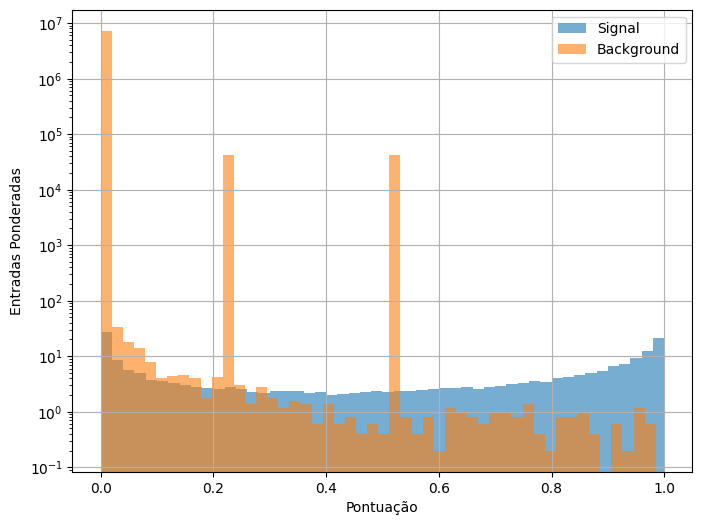

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Carregar arquivo
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# ==============================
# Separar sinal e background
# ==============================
signal = df[df["label"] == 1]
background = df[df["label"] == 0]

# ==============================
# Histograma com pesos
# ==============================
plt.figure(figsize=(8,6))

plt.hist(
    signal["score"],
    bins=50,
    weights=signal["weight"],
    alpha=0.6,
    label="Signal"
)

plt.hist(
    background["score"],
    bins=50,
    weights=background["weight"],
    alpha=0.6,
    label="Background"
)

plt.xlabel("Pontuação")
plt.ylabel("Entradas Ponderadas")
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.savefig("/home/levi/Área de Trabalho/Jupyter/Codes/Histograma_pontuação.png", dpi=100, bbox_inches='tight')
plt.show()


In [13]:
import pandas as pd
import numpy as np

# Luminosidade
L = 30000000  # pb^-1

# ==============================
# 1. Carregar o arquivo
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# ==============================
# 2. Separar sinal e background
# ==============================
signal_df = df[df["label"] == 1]
background_df = df[df["label"] == 0]

# ==============================
# 3. Integrar eventos
# ==============================
# (se for apenas contagem de eventos)
N_signal = len(signal_df)*L
N_background = len(background_df)*L

print("Integral (sinal):", N_signal)
print("Integral (background):", N_background)

# ==============================
# 4. Proporções nos dados
# ==============================
total_events = N_signal + N_background

prop_signal = N_signal / total_events
prop_background = N_background / total_events

print("Proporção sinal:", prop_signal)
print("Proporção background:", prop_background)

# ==============================
# 5. Cálculo da significância
# ==============================
# fórmula:    sig = S / sqrt(B)
if N_background > 0:
    significance = N_signal / np.sqrt(N_background)
else:
    significance = np.nan
    print("Background = 0 → não é possível calcular significância.")

print("Significância:", significance)


Integral (sinal): 1141410000000
Integral (background): 159990000000
Proporção sinal: 0.87706316274781
Proporção background: 0.12293683725218994
Significância: 2853614.176836436


In [7]:
import pandas as pd
import numpy as np

# ==============================
# 1. Carregar o CSV
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes.csv")

# ==============================
# 2. Aplicar o corte no score
# ==============================
signal_pred = df[df["score"] < 0.5]
background_pred = df[df["score"] > 0.5]

# ==============================
# 3. Integrais (contagem de eventos)
# ==============================
N_signal = len(signal_pred)
N_background = len(background_pred)

print("Integral (sinal predito):", N_signal)
print("Integral (background predito):", N_background)

# ==============================
# 4. Proporções
# ==============================
total = N_signal + N_background

prop_signal = N_signal / total
prop_background = N_background / total

print("Proporção sinal:", prop_signal)
print("Proporção background:", prop_background)

# ==============================
# 5. Significância
# ==============================
if N_background > 0:
    significance = N_signal / np.sqrt(N_background)
else:
    significance = np.nan
    print("Background = 0 → não é possível calcular significância.")

print("Significância (S / sqrt(B)):", significance)


Integral (sinal predito): 18511
Integral (background predito): 24869
Proporção sinal: 0.4267173812816966
Proporção background: 0.5732826187183033
Significância (S / sqrt(B)): 117.38178775545434


In [19]:
import pandas as pd
import numpy as np

# caminho do CSV
path = "/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv"

# carregar
df = pd.read_csv(path)

# verificar coluna weight; se não existir, assumir peso 1 para cada evento
if "weight" not in df.columns:
    print("A coluna 'weight' não foi encontrada. Assumindo weight = 1 para todos os eventos.")
    df["weight"] = 1.0
else:
    # garantir tipo numérico e tratar NaN
    df["weight"] = pd.to_numeric(df["weight"], errors="coerce").fillna(0.0)

# garantir que label exista e seja 0/1
if "label" not in df.columns:
    raise KeyError("Coluna 'label' não encontrada no arquivo. Precisa conter 0 (bkg) e 1 (sinal).")

# filtrar apenas labels válidos (0 e 1) e avisar sobre outros
valid_labels = df["label"].isin([0, 1])
if not valid_labels.all():
    n_bad = (~valid_labels).sum()
    print(f"Atenção: {n_bad} evento(s) com label diferente de 0/1 serão ignorados.")
df = df[valid_labels].copy()

# somas ponderadas por label
W_signal = df.loc[df["label"] == 1, "weight"].sum()
W_background = df.loc[df["label"] == 0, "weight"].sum()

# contagens de eventos (opcional)
N_signal = (df["label"] == 1).sum()
N_background = (df["label"] == 0).sum()

# proporções ponderadas
total_weight = W_signal + W_background
prop_signal = W_signal / total_weight if total_weight > 0 else np.nan
prop_background = W_background / total_weight if total_weight > 0 else np.nan

# significância (S / sqrt(B))
if W_background > 0:
    significance = W_signal / np.sqrt(W_background)
else:
    significance = np.nan

# resultados
print("---- Resultados ----")
print(f"Eventos sinal (count): {N_signal}")
print(f"Eventos background (count): {N_background}")
print(f"Integral ponderada sinal (sum weight, label=1): {W_signal:.6g}")
print(f"Integral ponderada background (sum weight, label=0): {W_background:.6g}")
print(f"Proporção ponderada sinal: {prop_signal:.6g}")
print(f"Proporção ponderada background: {prop_background:.6g}")
print(f"Significância (S/sqrt(B)): {significance:.6g}")


---- Resultados ----
Eventos sinal (count): 38047
Eventos background (count): 5333
Integral ponderada sinal (sum weight, label=1): 223.042
Integral ponderada background (sum weight, label=0): 7.33816e+06
Proporção ponderada sinal: 3.03939e-05
Proporção ponderada background: 0.99997
Significância (S/sqrt(B)): 0.0823367


In [20]:
import pandas as pd
import numpy as np

# ==============================
# 1. Carregar arquivo
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# ==============================
# 2. Separar sinal e background
# ==============================
signal_df = df[df["label"] == 1]
background_df = df[df["label"] == 0]

# ==============================
# 3. Integrar histogramas
# ==============================
# A integral do histograma = soma dos pesos
S = signal_df["weight"].sum()
B = background_df["weight"].sum()

print("Integral ponderada (Sinal) S:", S)
print("Integral ponderada (Background) B:", B)

# ==============================
# 4. Proporções (opcional)
# ==============================
total_weight = S + B
prop_signal = S / total_weight
prop_background = B / total_weight

print("Proporção sinal:", prop_signal)
print("Proporção background:", prop_background)

# ==============================
# 5. Calcular significância
# ==============================
if B > 0:
    significance = S / np.sqrt(B)
else:
    significance = np.nan
    print("Background = 0, não é possível calcular significância.")

print("Significância:", significance)


Integral ponderada (Sinal) S: 223.04209931579848
Integral ponderada (Background) B: 7338156.867296206
Proporção sinal: 3.0393915560331212e-05
Proporção background: 0.9999696060844396
Significância: 0.08233667945302375


In [12]:
import pandas as pd
import numpy as np

# Luminosidade
L = 30000000  # pb^-1

# ==============================
# 1. Carregar arquivo
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# ==============================
# 2. Aplicar corte no score
# ==============================
df_cut = df[df["score"] > 0.5]

# ==============================
# 3. Separar sinal e background (após corte)
# ==============================
signal_df = df_cut[df_cut["label"] == 1]
background_df = df_cut[df_cut["label"] == 0]

# ==============================
# 4. Integrar histogramas (somar pesos)
# ==============================
S = signal_df["weight"].sum()
B = background_df["weight"].sum()

print("Integral ponderada após corte (Sinal) S:", S)
print("Integral ponderada após corte (Background) B:", B)

# ==============================
# 5. Calcular significância
# ==============================
if B > 0:
    significance = S / np.sqrt(B)
else:
    significance = np.nan
    print("Background = 0 → não é possível calcular significância.")

print("Significância após corte:", significance)


Integral ponderada após corte (Sinal) S: 122.36917734329916
Integral ponderada após corte (Background) B: 41823.64780932304
Significância após corte: 0.5983579781133249


In [18]:
import pandas as pd
import numpy as np

# Luminosidade
L = 30000000  # pb^-1

# ==============================
# 1. Carregar arquivo
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# ==============================
# 2. Aplicar corte no score
# ==============================
df_cut = df[df["score"] > 0.1]

# ==============================
# 3. Separar sinal e background (após corte)
# ==============================
signal_df = df_cut[df_cut["label"] == 1]
background_df = df_cut[df_cut["label"] == 0]

# ==============================
# 4. Integrar histogramas (somar pesos)
# ==============================
S = signal_df["weight"].sum()
B = background_df["weight"].sum()

print("Integral ponderada após corte (Sinal) S:", S)
print("Integral ponderada após corte (Background) B:", B)

# ==============================
# 5. Criar histogramas e escalonar (equivalente ao ROOT)
# ==============================
N_bins = 50

# Histograma do sinal
hist_signal, bin_edges = np.histogram(
    signal_df["score"],
    bins=N_bins,
    weights=signal_df["weight"]
)

# Histograma do background
hist_background, _ = np.histogram(
    background_df["score"],
    bins=N_bins,
    weights=background_df["weight"]
)

# Largura das bins
bin_width = bin_edges[1] - bin_edges[0]
print("Largura do bin:", bin_width)

# Escalonamento ROOT-like: h.Scale(1/bin_width)
hist_signal_scaled = hist_signal / bin_width
hist_background_scaled = hist_background / bin_width

print("\nHistograma sinal escalonado (primeiros bins):", hist_signal_scaled[:5])
print("Histograma background escalonado (primeiros bins):", hist_background_scaled[:5])

# ==============================
# 6. Calcular significância
# ==============================
# A integral verdadeira é a NÃO escalonada (ROOT faz assim!)
if B > 0:
    significance = S / np.sqrt(B)
else:
    significance = np.nan
    print("Background = 0 → não é possível calcular significância.")

print("\nSignificância após corte:", significance)


Integral ponderada após corte (Sinal) S: 172.4330287208988
Integral ponderada após corte (Background) B: 83671.33085379304
Largura do bin: 0.017996861000000003

Histograma sinal escalonado (primeiros bins): [177.52520836 161.89253954 156.35324307 142.02620659 140.71629886]
Histograma background escalonado (primeiros bins): [198.67295336 220.74772595 220.74772595 187.63556706 143.48602187]

Significância após corte: 0.5961178385414673


In [19]:
import pandas as pd
import numpy as np

# ==============================
# 1. Carregar arquivo
# ==============================
df = pd.read_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv")

# ==============================
# Preparar lista onde vamos salvar resultados
# ==============================
results = []

# Gerar cortes de 0.0 a 1.0 com passo 0.1
cuts = np.arange(0.0, 1.01, 0.1)

for cut in cuts:
    # ==============================
    # 2. Aplicar corte no score
    # ==============================
    df_cut = df[df["score"] > cut]

    # ==============================
    # 3. Separar sinal e background
    # ==============================
    signal_df = df_cut[df_cut["label"] == 1]
    background_df = df_cut[df_cut["label"] == 0]

    # ==============================
    # 4. Integrar histogramas (somar pesos)
    # ==============================
    S = signal_df["weight"].sum()
    B = background_df["weight"].sum()

    # ==============================
    # 6. Calcular significância
    # ==============================
    if B > 0:
        significance = S / np.sqrt(B)
    else:
        significance = np.nan

    # Salvar no vetor
    results.append([cut, S, B, significance])

# ==============================
# 7. Transformar em DataFrame bonito
# ==============================
result_df = pd.DataFrame(results, columns=["cut", "S", "B", "significance"])

print(result_df)


    cut           S             B  significance
0   0.0  223.042099  7.338157e+06      0.082337
1   0.1  172.433029  8.367133e+04      0.596118
2   0.2  157.179345  8.365306e+04      0.543444
3   0.3  144.856551  4.183378e+04      0.708230
4   0.4  133.319810  4.182722e+04      0.651876
5   0.5  122.369177  4.182365e+04      0.598358
6   0.6  110.410310  1.410332e+01     29.400110
7   0.7   96.792212  9.534639e+00     31.346445
8   0.8   80.360265  5.760511e+00     33.481959
9   0.9   57.004677  2.582298e+00     35.473767
10  1.0    0.000000  0.000000e+00           NaN


In [21]:
import pandas as pd

# Caminho do arquivo
path = "/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_v2.csv"

# Carrega o CSV
df = pd.read_csv(path)

# Aplica o corte: score > 0.5
df_cortado = df[(df['score'] > 0.5)]

# Opcional: salvar o arquivo filtrado
df_cortado.to_csv("/home/levi/Área de Trabalho/Jupyter/Codes/scores_independentes_cut.csv", index=False)

print("Eventos antes:", len(df))
print("Eventos depois:", len(df_cortado))


Eventos antes: 43380
Eventos depois: 20964
